### Example Fixed Project

The rest of this tutorial uses pre compiled ORBIT configs that are stored as .yaml files in the '~/configs/ folder. There are load and save methods available in ORBIT for working with .yaml files. These example projects each exhibit different functionalities within ORBIT. Using these examples and combinations of them, most project configurations can be modeled. 

In [1]:
import os
import pandas as pd
from ORBIT import ProjectManager, load_config

weather = pd.read_csv("data/boem_era5_41.0_-71.0.csv", parse_dates=["datetime"])\
            .set_index("datetime")

### Load the project configuration

In [2]:
fixed_config = load_config("configs/Sunrise_Wind_High_base_install.yaml")  # Configs can be loaded with absolute or relative paths

print(type(fixed_config))                                         # They are loaded in as dictionaries.

print(f"Num turbines: {fixed_config['plant']['num_turbines']}")   # Once a configuration is loaded, different parameters can  
print(f"Turbine: {fixed_config['turbine']}")                      # be accessed using dict access.
print(f"\nSite: {fixed_config['site']}")

<class 'dict'>
Num turbines: 84
Turbine: 11MW_generic

Site: {'depth': 47.52, 'distance': 103, 'distance_to_landfall': 169, 'mean_windspeed': 8.16811714317274}


### Phases

This fixed project represents a generic Offshore Wind farm with 50 6MW turbines. It includes 5 design modules and 6 installation modules as seen below. This is a common set of modules to run for a fixed bottom project. This config will model the procurement and installation of monopiles, scour protection, array system, export system, offshore substation and the turbines.

In [3]:
print(f"Design phases: {fixed_config['design_phases']}")
print(f"\nInstall phases: {list(fixed_config['install_phases'].keys())}")

Design phases: ['MonopileDesign', 'ScourProtectionDesign', 'CustomArraySystemDesign', 'ElectricalDesign']

Install phases: ['ArrayCableInstallation', 'ExportCableInstallation', 'MonopileInstallation', 'OffshoreSubstationInstallation', 'ScourProtectionInstallation', 'TurbineInstallation']


### Run

This project is always being modeled with the example weather project supplied that is representative of US East Coast wind farm locations.

In [4]:
project = ProjectManager(fixed_config, weather=weather)
project.run()

ORBIT library intialized at 'C:\ORBIT_procurement_by_year\ORBIT-dev\ORBIT\library'


Missing data in columns ['cable_length', 'bury_speed']; all values will be calculated.DeprecationWarning: C:\ORBIT_procurement_by_year\ORBIT-dev\ORBIT\ORBIT\manager.py:730
landfall dictionary will be deprecated and moved into [export_system][landfall].

TurbineInstallation:
TurbineInstallation:


### Top Level Outputs

ProjectManager offers several high level result categories:
- Installation CapEx
- System CapEx (procurement of BOS subcomponents)
- Turbine CapEx
- Soft CapEx (project management costs)
- Total CapEx
- Total installation time
- etc.

In [5]:
print(f"Installation CapEx:  {project.installation_capex/1e6:.0f} M")
print(f"System CapEx:        {project.system_capex/1e6:.0f} M")
print(f"Turbine CapEx:       {project.turbine_capex/1e6:.0f} M")
print(f"Soft CapEx:          {project.soft_capex/1e6:.0f} M")
print(f"Total CapEx:        {project.total_capex/1e6:.0f} M")

print(f"\nInstallation Time: {project.installation_time:.0f} h")

Installation CapEx:  1193 M
System CapEx:        2414 M
Turbine CapEx:       1653 M
Soft CapEx:          1818 M
Total CapEx:        7631 M

Installation Time: 45534 h


### CapEx Breakdown

In [6]:
# The breakdown of project costs by module is available  at 'capex_breakdown'
data = project.capex_detailed_soft_capex_breakdown

# Convert the dictionary into a pandas DataFrame
df = pd.DataFrame(list(data.items()), columns=['Category', 'Value'])

# Add a "Total" row
total_row = pd.DataFrame([['Total', df['Value'].sum()]], columns=['Category', 'Value'])
df = pd.concat([df, total_row], ignore_index=True)

# Display the DataFrame
df.to_csv("Sunrise_Wind_High_fixed_costs.csv")
display(df)

,Category,Value
0,Array System,1.223526e+08
1,Export System,3.546855e+08
2,Offshore Substation,7.944481e+08
3,Scour Protection,2.399040e+07
4,Substructure,1.118924e+09
5,Array System Installation,1.262365e+08
6,Export System Installation,4.501802e+07
7,Offshore Substation Installation,1.733841e+08
8,Scour Protection Installation,4.801704e+07
9,Substructure Installation,6.016822e+08


In [7]:
project.phases['ElectricalDesign'].detailed_output

{'export_system': {'landfall': {'interconnection_distance': 28},
  'system_cost': np.float64(354685536.0),
  'cable': {'linear_density': 53,
   'sections': [197.04752],
   'number': 2,
   'cable_power': 1216.0,
   'cable_type': 'HVDC-monopole'},
  'onshore_substation_costs': 254763736},
 'offshore_substation': {'substation_mpt_cost': 0,
  'substation_shunt_cost': 0,
  'substation_switchgear_cost': 0,
  'substation_converter_cost': 228600000,
  'substation_breaker_cost': 21899462,
  'substation_ancillary_cost': 7570751,
  'substation_land_assembly_cost': 567806.325},
 'offshore_substation_substructure': {'type': 'Monopile',
  'deck_space': 1,
  'mass': 2259.569572851544,
  'length': 57.52,
  'unit_cost': 6610124.0},
 'offshore_substation_topside': {'deck_space': 1,
  'mass': 4366.0,
  'unit_cost': 787838019.325},
 'num_substations': 1,
 'total_substation_cost': 794448143.325,
 'export_system_total_mass': 20887.03712,
 'export_system_total_length': 394.09504,
 'export_system_total_cost':

In [8]:
# The breakdown of project costs by module is available  at 'capex_breakdown'
data = project.capex_detailed_soft_capex_breakdown_per_kw

# Convert the dictionary into a pandas DataFrame
df = pd.DataFrame(list(data.items()), columns=['Category', 'Value'])

# Add a "Total" row
total_row = pd.DataFrame([['Total', df['Value'].sum()]], columns=['Category', 'Value'])
df = pd.concat([df, total_row], ignore_index=True)

# Display the DataFrame
df.to_csv("Sunrise_Wind_High_fixed_costs_per_kw.csv")
display(df)

,Category,Value
0,Array System,132.416199
1,Export System,383.858805
2,Offshore Substation,859.792363
3,Scour Protection,25.963636
4,Substructure,1210.957145
5,Array System Installation,136.619612
6,Export System Installation,48.720804
7,Offshore Substation Installation,187.645106
8,Scour Protection Installation,51.966490
9,Substructure Installation,651.171182


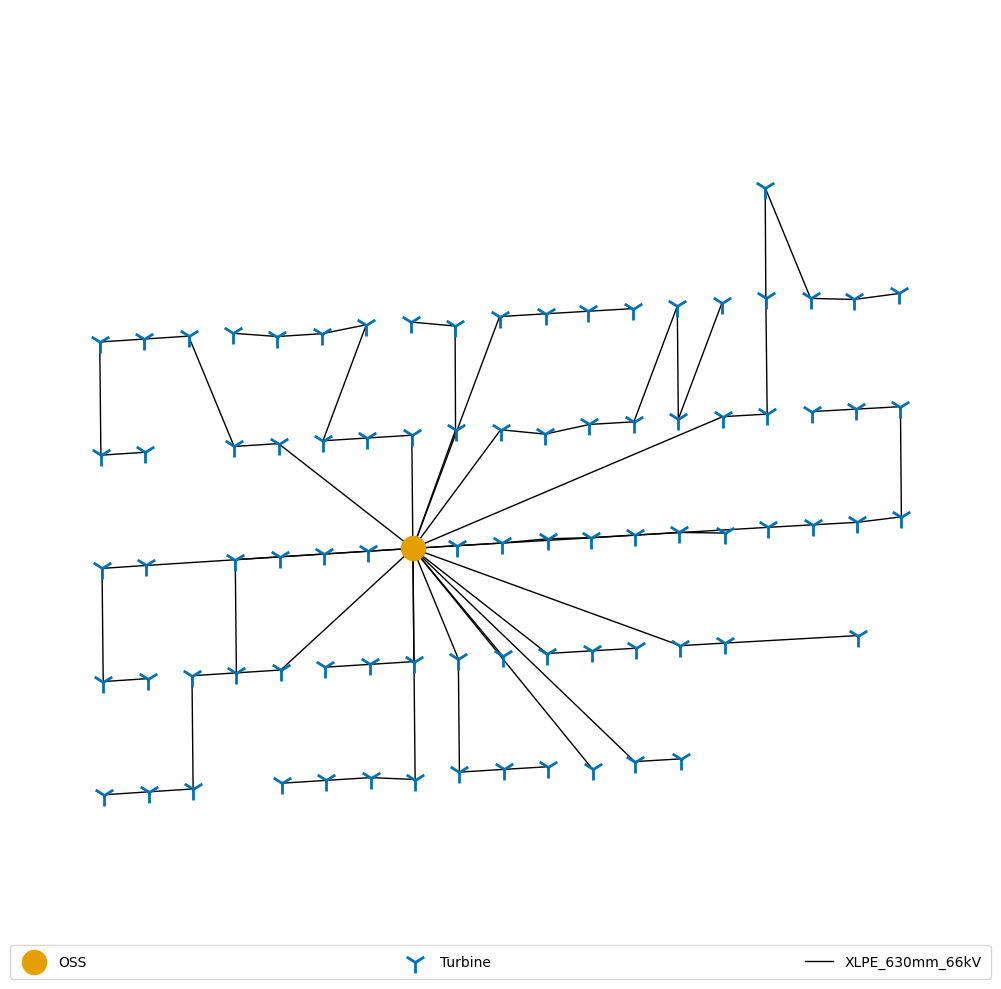

In [9]:
project.phases['CustomArraySystemDesign'].plot_array_system(show=True)

### Installation Actions

In [10]:
df = pd.DataFrame(project.actions)    # The project simulation logs are also available for all modules
df

,cost_multiplier,agent,action,duration,cost,level,time,phase,location,phase_name,max_waveheight,max_windspeed,transit_speed,site_depth,hub_height
0,0.5,Array Cable Installation Vessel,Mobilize,72.0,3.617565e+05,ACTION,0.000000,ArrayCableInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.5,Export Cable Installation Vessel,Mobilize,72.0,3.617565e+05,ACTION,0.000000,ExportCableInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.5,Export Cable Burial Vessel,Mobilize,72.0,3.617565e+05,ACTION,0.000000,ExportCableInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Onshore Construction,Onshore Construction,0.0,1.226009e+07,ACTION,0.000000,ExportCableInstallation,Landfall,NaN,NaN,NaN,NaN,NaN,NaN
4,0.5,Heavy Lift Vessel,Mobilize,72.0,9.369180e+05,ACTION,0.000000,OffshoreSubstationInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6612,NaN,WTIV,Transit,105.0,1.750000e+06,ACTION,18132.515025,MonopileInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6613,NaN,WTIV,Delay,1.0,1.666667e+04,ACTION,18133.515025,MonopileInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6614,NaN,WTIV,Transit,10.3,1.716667e+05,ACTION,18143.815025,MonopileInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6615,NaN,Feeder 0,Delay,457.0,2.803676e+06,ACTION,18400.698225,MonopileInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# These logs can be sorted by phase by using DataFrame operations

turbine_install = df.loc[df['phase']=="ExportCableInstallation"]
turbine_install

,cost_multiplier,agent,action,duration,cost,level,time,phase,location,phase_name,max_waveheight,max_windspeed,transit_speed,site_depth,hub_height
1,0.5,Export Cable Installation Vessel,Mobilize,72.0,3.617565e+05,ACTION,0.000000,ExportCableInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.5,Export Cable Burial Vessel,Mobilize,72.0,3.617565e+05,ACTION,0.000000,ExportCableInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Onshore Construction,Onshore Construction,0.0,1.226009e+07,ACTION,0.000000,ExportCableInstallation,Landfall,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,Export Cable Installation Vessel,Load Cable,6.0,6.029275e+04,ACTION,6.000000,ExportCableInstallation,NaN,ExportCableInstallation,NaN,NaN,NaN,NaN,NaN
10,NaN,Export Cable Installation Vessel,Tow Plow,5.6,5.627323e+04,ACTION,11.600000,ExportCableInstallation,NaN,ExportCableInstallation,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
474,NaN,Export Cable Burial Vessel,Bury Cable,43.0,4.320980e+05,ACTION,2285.470974,ExportCableInstallation,NaN,ExportCableInstallation,2.0,25.0,11.5,NaN,NaN
477,NaN,Export Cable Burial Vessel,Delay,18.0,1.808782e+05,ACTION,2303.470974,ExportCableInstallation,NaN,ExportCableInstallation,2.0,25.0,11.5,NaN,NaN
491,NaN,Export Cable Burial Vessel,Bury Cable,36.0,3.617565e+05,ACTION,2339.470974,ExportCableInstallation,NaN,ExportCableInstallation,2.0,25.0,11.5,NaN,NaN
494,NaN,Export Cable Burial Vessel,Delay,10.0,1.004879e+05,ACTION,2349.470974,ExportCableInstallation,NaN,ExportCableInstallation,2.0,25.0,11.5,NaN,NaN


In [12]:
# Operations can also be grouped to see a total amount of time spend on each operation

turbine_install.groupby(["action"]).sum()['duration']

action
Bury Cable              492.500000
Delay                   792.000000
Lay Cable               492.618800
Load Cable                6.000000
Lower Cable               1.000000
Mobilize                144.000000
Onshore Construction      0.000000
Position Onsite           2.000000
Prepare Cable             1.000000
Pull In Cable            11.000000
Pull Winch                5.600000
Terminate Cable          11.000000
Tow Plow                  5.600000
Transit                 557.652174
Name: duration, dtype: float64